# Adaptive Thresholding v2 — Blended (Shrinkage) Design

Input: `models/vae_cc1.pt` / `vae_cc1_meta.pkl` / `vae_cc1_eval.pkl` /
`vae_cc1_adaptive_eval.pkl` (from `train_vae.ipynb`, `vae_eval.ipynb`,
`adaptive_threshold.ipynb`) and `data/processed/{cc1_test,drift_*}.csv` +
`data/processed/windows_cc1/*.npy`.

**Why this notebook exists:** `adaptive_threshold.ipynb` implemented the Module 3
spec literally — a per-container threshold from *only* that container's last 500
reconstruction errors. That underperformed the static baseline in 3 of 4 sets,
verified correct (not a bug): 500 local samples is too small a sample to beat
154,198 pooled ones, so the local estimate was too noisy.

**The fix:** don't replace the global (static) estimate with a small local one —
**blend** them, with the blend weight shifting toward local evidence only as a
container accumulates enough of its own history:

```
w = n_local / (n_local + PRIOR_STRENGTH)
threshold = [w * local_mean + (1-w) * global_mean] + k * [w * local_std + (1-w) * global_std]
```

`PRIOR_STRENGTH` controls how "sticky" the global prior is — a pseudo-count of how
much local evidence it takes before local data gets equal say. When a container has
no history (`n_local=0`), `w=0` and this **exactly reduces to the static threshold**
— no separate burn-in branch needed, unlike the naive version.

**Oracle-ceiling reminder (why we expect this to help *some* sets and not others):**
`drift_cc2` static F1=0.276, ceiling=0.511 (real room); `drift_sc2` static
F1=0.024, ceiling=0.160 (some room); `drift_sc1` static F1=0.040, ceiling=0.060
(no room — don't expect improvement there); `cc1_test` already near its own
ceiling (no drift to correct for).

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle, os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from collections import deque

BASE      = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
DATA_DIR  = os.path.join(BASE, 'data', 'processed')
WIN_DIR   = os.path.join(BASE, 'data', 'processed', 'windows_cc1')
MODEL_DIR = os.path.join(BASE, 'models')

WINDOW_SIZE = 30
BUFFER_SIZE = 500   # kept fixed at the value already justified in adaptive_threshold.ipynb (~2h local coverage)
K_ADAPTIVE  = 3.0    # same convention used throughout

SPLIT_FILES = {
    'cc1_val':   'cc1_val.csv',
    'cc1_test':  'cc1_test.csv',
    'drift_sc1': 'drift_single_case1.csv',
    'drift_sc2': 'drift_single_case2.csv',
    'drift_cc2': 'drift_complex_case2.csv',
}
DRIFT_SETS = ['drift_sc1', 'drift_sc2', 'drift_cc2']

print('Paths and constants configured.')

Paths and constants configured.


## Step 1 — Load model + prior results (static + naive adaptive, for a 3-way comparison)

In [2]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden1), nn.ReLU(), nn.Linear(hidden1, hidden2), nn.ReLU())
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden2), nn.ReLU(), nn.Linear(hidden2, hidden1), nn.ReLU(), nn.Linear(hidden1, input_dim))
    def encode(self, x):
        h = self.encoder(x); return self.fc_mu(h), torch.clamp(self.fc_lv(h), -10, 10)
    def decode(self, z): return self.decoder(z)
    @torch.no_grad()
    def anomaly_score(self, x):
        self.eval(); mu, _ = self.encode(x); return ((self.decode(mu) - x) ** 2).mean(dim=1)

meta            = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_meta.pkl'), 'rb'))
static_eval      = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_eval.pkl'), 'rb'))
naive_adaptive   = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_adaptive_eval.pkl'), 'rb'))

GLOBAL_MEAN = meta['mu_train']
GLOBAL_STD  = meta['sigma_train']
print(f'Global (static) prior: mean={GLOBAL_MEAN:.5f}  std={GLOBAL_STD:.5f}')

model = VAE(meta['input_dim'], meta['hidden1'], meta['hidden2'], meta['latent_dim'])
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'vae_cc1.pt'), map_location='cpu'))
model.eval()
CLIP = meta['clip']
print('Model loaded.')

Global (static) prior: mean=0.02218  std=0.03201
Model loaded.


## Step 2 — Load data + recover per-window `cmdb_id`

Same replay-and-verify approach as `adaptive_threshold.ipynb` — reproduces the
container label for each window and checks it against the saved `y` array before
trusting it.

In [3]:
def window_meta(df, window_size, stride=1):
    cmdb_ids, end_ts, ys = [], [], []
    for cmdb_id, g in df.sort_values('timestamp').groupby('cmdb_id'):
        is_gap = g['is_gap'].values
        labels = g['label'].values
        ts     = g['timestamp'].values
        n = len(g)
        for i in range(0, n - window_size + 1, stride):
            if is_gap[i:i + window_size].any():
                continue
            cmdb_ids.append(cmdb_id)
            end_ts.append(ts[i + window_size - 1])
            ys.append(int(labels[i:i + window_size].any()))
    return np.array(cmdb_ids), np.array(end_ts), np.array(ys, dtype=np.int64)

cmdb_ids, end_ts, y, ft, mse = {}, {}, {}, {}, {}
for name, fname in SPLIT_FILES.items():
    df = pd.read_csv(os.path.join(DATA_DIR, fname), low_memory=False)
    df['is_gap'] = df['is_gap'].astype(bool)
    cmdb_ids[name], end_ts[name], y_replayed = window_meta(df, WINDOW_SIZE)

    y[name]  = np.load(os.path.join(WIN_DIR, f'y_{name}.npy'))
    ft[name] = np.load(os.path.join(WIN_DIR, f'ft_{name}.npy'), allow_pickle=True)
    Xr       = np.load(os.path.join(WIN_DIR, f'X_{name}.npy'))
    X        = np.clip(Xr, -CLIP, CLIP).astype(np.float32)
    mse[name] = model.anomaly_score(torch.from_numpy(X)).numpy()

    match = np.array_equal(y_replayed, y[name])
    print(f'  {name:10s}: {len(y[name]):>7,} windows  |  cmdb_id/order check: {"OK" if match else "MISMATCH!"}')
    assert match, f'{name}: ordering mismatch — cannot trust cmdb_id segmentation.'

  cc1_val   :  21,573 windows  |  cmdb_id/order check: OK
  cc1_test  :  44,185 windows  |  cmdb_id/order check: OK
  drift_sc1 :  59,697 windows  |  cmdb_id/order check: OK
  drift_sc2 :  38,070 windows  |  cmdb_id/order check: OK
  drift_cc2 :  76,977 windows  |  cmdb_id/order check: OK


## Step 3 — Blended (shrinkage) adaptive-threshold algorithm

`w = n_local / (n_local + PRIOR_STRENGTH)` — starts at 0 (pure static) and rises
toward 1 (pure local) only as the container's own buffer fills up. Mean and std
are blended the same way (a simplification — not a fully rigorous Bayesian
variance update, but transparent and easy to reason about). Same robust rule as
before: only points classified normal get added to the buffer.

In [4]:
def run_blended(mse_arr, cmdb_arr, prior_strength, buffer_size=BUFFER_SIZE, k=K_ADAPTIVE,
                 global_mean=GLOBAL_MEAN, global_std=GLOBAL_STD):
    n = len(mse_arr)
    preds = np.zeros(n, dtype=np.int64)
    thresh_used = np.zeros(n, dtype=np.float64)
    weight_used = np.zeros(n, dtype=np.float64)
    buffers = {}

    for i in range(n):
        cid = cmdb_arr[i]
        buf = buffers.setdefault(cid, deque(maxlen=buffer_size))
        n_local = len(buf)
        w = n_local / (n_local + prior_strength)

        if n_local == 0:
            local_mean, local_std = global_mean, global_std   # irrelevant: w=0 anyway
        else:
            arr = np.fromiter(buf, dtype=np.float64)
            local_mean, local_std = arr.mean(), arr.std()

        blended_mean = w * local_mean + (1 - w) * global_mean
        blended_std  = w * local_std  + (1 - w) * global_std
        t = blended_mean + k * blended_std

        thresh_used[i] = t
        weight_used[i] = w
        is_anom = mse_arr[i] > t
        preds[i] = int(is_anom)
        if not is_anom:
            buf.append(mse_arr[i])
    return preds, thresh_used, weight_used

print('Blended-threshold function defined.')

Blended-threshold function defined.


## Step 4 — Calibrate `PRIOR_STRENGTH` on `cc1_val` (unsupervised, no anomaly labels)

Same no-leakage discipline as every threshold chosen so far in this pipeline —
`cc1_val` is 100% normal, so this only checks the resulting false-positive rate,
never F1. Target ~1%, matching `val_p99`'s original intent.

In [5]:
PRIOR_CANDIDATES = [100, 500, 2000, 10000, 50000]
print(f'{"prior_strength":>14s} {"FPR on cc1_val":>16s}')
prior_fpr = {}
for ps in PRIOR_CANDIDATES:
    preds, _, _ = run_blended(mse['cc1_val'], cmdb_ids['cc1_val'], prior_strength=ps)
    fpr = preds.mean()
    prior_fpr[ps] = fpr
    print(f'{ps:14d} {fpr*100:15.2f}%')

BEST_PRIOR = min(PRIOR_CANDIDATES, key=lambda ps: abs(prior_fpr[ps] - 0.01))
print(f'\nChosen PRIOR_STRENGTH = {BEST_PRIOR}  (closest to the 1% target)')

prior_strength   FPR on cc1_val
           100            1.58%
           500            1.02%
          2000            0.78%
         10000            0.68%
         50000            0.67%

Chosen PRIOR_STRENGTH = 500  (closest to the 1% target)


## Step 5 — Three-way comparison: static vs. naive adaptive vs. blended adaptive

In [6]:
blended_results = {}
print(f'{"set":12s} {"method":10s} {"precision":>10s} {"recall":>8s} {"f1":>7s} {"TP":>5s} {"FP":>6s} {"FN":>5s} {"TN":>7s}')
for name in ['cc1_test'] + DRIFT_SETS:
    preds, thresh_used, weight_used = run_blended(mse[name], cmdb_ids[name], prior_strength=BEST_PRIOR)
    p = precision_score(y[name], preds, zero_division=0)
    r = recall_score(y[name], preds, zero_division=0)
    f1 = f1_score(y[name], preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y[name], preds).ravel()
    blended_results[name] = {'precision': p, 'recall': r, 'f1': f1, 'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
                              'thresh_used': thresh_used, 'weight_used': weight_used, 'preds': preds}
    print(f'{name:12s} {"blended":10s} {p:10.3f} {r:8.3f} {f1:7.3f} {tp:5d} {fp:6d} {fn:5d} {tn:7d}')

    st = static_eval['precision_recall'][name]['val_p99']
    na = naive_adaptive['results'][name]
    print(f'{name:12s} {"static":10s} {st["precision"]:10.3f} {st["recall"]:8.3f} {st["f1"]:7.3f} '
          f'{st["tp"]:5d} {st["fp"]:6d} {st["fn"]:5d} {st["tn"]:7d}')
    print(f'{name:12s} {"naive_adap":10s} {na["precision"]:10.3f} {na["recall"]:8.3f} {na["f1"]:7.3f} '
          f'{na["tp"]:5d} {na["fp"]:6d} {na["fn"]:5d} {na["tn"]:7d}')
    print(f'  -> blended vs static F1 change:       {f1 - st["f1"]:+.3f}')
    print(f'  -> blended vs naive-adaptive F1 change: {f1 - na["f1"]:+.3f}\n')

set          method      precision   recall      f1    TP     FP    FN      TN
cc1_test     blended         0.676    0.578   0.623   148     71   108   43858
cc1_test     static          0.630    0.605   0.618   155     91   101   43838
cc1_test     naive_adap      0.094    0.617   0.164   158   1517    98   42412
  -> blended vs static F1 change:       +0.006
  -> blended vs naive-adaptive F1 change: +0.460

drift_sc1    blended         0.024    0.813   0.047   109   4421    25   55142
drift_sc1    static          0.020    0.806   0.040   108   5169    26   54394
drift_sc1    naive_adap      0.019    0.948   0.037   127   6531     7   53032
  -> blended vs static F1 change:       +0.007
  -> blended vs naive-adaptive F1 change: +0.009

drift_sc2    blended         0.020    0.494   0.039    42   2040    43   35945
drift_sc2    static          0.012    0.482   0.024    41   3358    44   34627
drift_sc2    naive_adap      0.021    0.635   0.041    54   2513    31   35472
  -> blended vs 

## Step 6 — Visualize the blend weight and threshold over time

Same example container as `adaptive_threshold.ipynb`, so the two plots are
directly comparable. Watch the weight (`w`) climb from 0 — the threshold should
start at the static value and only gradually drift toward a local one, unlike the
naive version's hard jump at `MIN_BUFFER`.

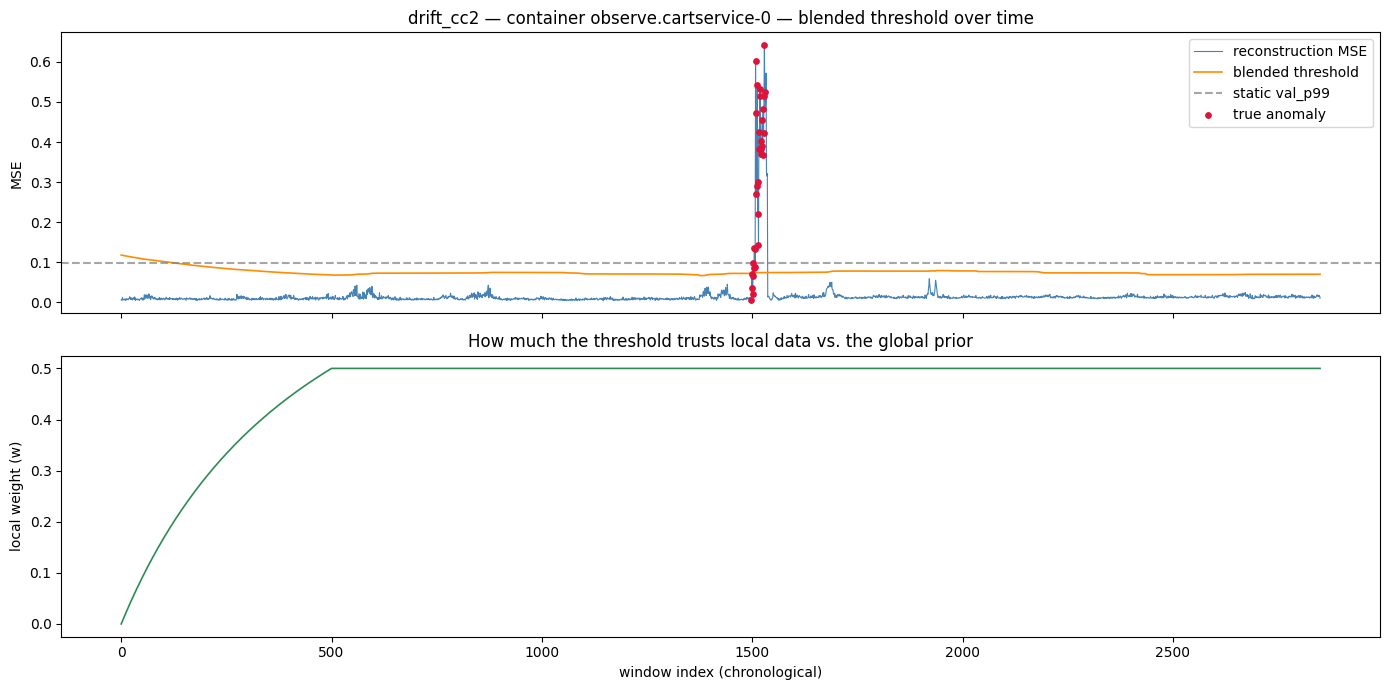

In [7]:
EXAMPLE_SET = 'drift_cc2'
example_containers = np.unique(cmdb_ids[EXAMPLE_SET])
EXAMPLE_CID = example_containers[0]
mask = cmdb_ids[EXAMPLE_SET] == EXAMPLE_CID

r = blended_results[EXAMPLE_SET]
thresh_ex, weight_ex = r['thresh_used'][mask], r['weight_used'][mask]
mse_ex = mse[EXAMPLE_SET][mask]
y_ex   = y[EXAMPLE_SET][mask]
ts_ex  = end_ts[EXAMPLE_SET][mask]
order  = np.argsort(ts_ex)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(mse_ex[order], color='steelblue', lw=0.8, label='reconstruction MSE')
axes[0].plot(thresh_ex[order], color='darkorange', lw=1.2, label='blended threshold')
axes[0].axhline(static_eval['thresholds']['val_p99'], ls='--', color='gray', alpha=0.7, label='static val_p99')
anom_idx = np.where(y_ex[order] == 1)[0]
if len(anom_idx):
    axes[0].scatter(anom_idx, mse_ex[order][anom_idx], color='crimson', zorder=5, s=15, label='true anomaly')
axes[0].set_title(f'{EXAMPLE_SET} — container {EXAMPLE_CID} — blended threshold over time')
axes[0].set_ylabel('MSE'); axes[0].legend()

axes[1].plot(weight_ex[order], color='seagreen', lw=1.2)
axes[1].set_ylabel('local weight (w)'); axes[1].set_xlabel('window index (chronological)')
axes[1].set_title('How much the threshold trusts local data vs. the global prior')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_blended_example.png'), dpi=120)
plt.show()

## Step 7 — Per-fault-type recall, three-way comparison

In [8]:
print(f'{"set":12s} {"fault_type":14s} {"n":>5s} {"static":>8s} {"naive_adap":>11s} {"blended":>9s}')
per_fault_blended = {}
for name in ['cc1_test'] + DRIFT_SETS:
    per_fault_blended[name] = {}
    preds = blended_results[name]['preds']
    types_present = sorted({v for v in ft[name] if isinstance(v, str)})
    for ftype in types_present:
        fmask = (ft[name] == ftype)
        n = int(fmask.sum())
        rec_blend = preds[fmask].mean() if n > 0 else float('nan')
        rec_static = static_eval['per_fault_recall'][name][ftype]['recall']
        rec_naive  = naive_adaptive['per_fault_recall'][name][ftype]['recall']
        per_fault_blended[name][ftype] = {'n': n, 'recall': rec_blend}
        print(f'{name:12s} {ftype:14s} {n:5d} {rec_static:8.3f} {rec_naive:11.3f} {rec_blend:9.3f}')
    print()

set          fault_type         n   static  naive_adap   blended
cc1_test     cpu               88    0.580       0.580     0.557
cc1_test     memory            76    0.763       0.763     0.724
cc1_test     pod-failure       92    0.500       0.533     0.478

drift_sc1    cpu               65    0.908       0.923     0.908
drift_sc1    memory            69    0.710       0.971     0.725

drift_sc2    pod-failure       85    0.482       0.635     0.494

drift_cc2    cpu              207    0.908       0.932     0.913
drift_cc2    memory           414    0.713       0.906     0.727
drift_cc2    pod-failure       99    0.737       0.919     0.768



## Step 8 — Save results

In [9]:
save_results = {
    'buffer_size':      BUFFER_SIZE,
    'k_adaptive':        K_ADAPTIVE,
    'prior_strength':    BEST_PRIOR,
    'prior_fpr_search':  prior_fpr,
    'results':           {name: {k: v for k, v in r.items() if k not in ('thresh_used', 'weight_used', 'preds')} for name, r in blended_results.items()},
    'per_fault_recall':  per_fault_blended,
}
out_path = os.path.join(MODEL_DIR, 'vae_cc1_adaptive_blended_eval.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(save_results, f)
print(f'Saved -> {out_path}')

Saved -> c:\Users\jthar\Documents\Claude\Projects\module3\models\vae_cc1_adaptive_blended_eval.pkl


## Summary

Compare the three F1 columns printed in Step 5 against the oracle ceilings from
`vae_eval.ipynb`'s follow-up analysis:

| set | static F1 | naive-adaptive F1 | blended F1 (this notebook) | oracle ceiling |
|---|---|---|---|---|
| cc1_test | 0.618 | 0.164 | *(see Step 5)* | ~static (no drift to fix) |
| drift_sc1 | 0.040 | 0.037 | *(see Step 5)* | 0.060 (don't expect improvement) |
| drift_sc2 | 0.024 | 0.041 | *(see Step 5)* | 0.160 (some room) |
| drift_cc2 | 0.276 | 0.185 | *(see Step 5)* | 0.511 (real room) |

If blended beats static on `drift_cc2` and roughly matches it on `cc1_test`, the
shrinkage fix worked as intended. If `drift_sc1` still doesn't move, that's
expected and correct, not a failure of this notebook — that set's limitation was
never about the threshold.